In [22]:
from typing import List, Optional, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama

In [23]:
model = ChatOllama(model="llama3.2:3b")

In [24]:
class BestTeam(TypedDict):
    team: str
    players: List[str]
    strategy: str

In [35]:
def create_teams(state: BestTeam) -> BestTeam:
    team = state["team"]

    prompt = f"""
You are a sports analyst. Create a list of players for the team '{team}' and suggest a strategy for the team to win the championship. Provide the players in a list format and the strategy in a concise manner."""

    players = model.invoke(prompt).content
    state["players"] = players
    return state

def suggest_strategy(state: BestTeam) -> BestTeam:
    players = state["players"]

    prompt = f"""
You are a sports strategist. Given the following players: {players}, suggest a winning strategy for the team. Provide the strategy in a concise manner."""
    strategy = model.invoke(prompt).content
    state["strategy"] = strategy
    return state

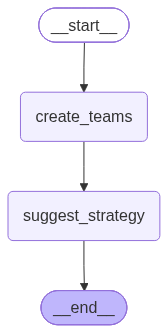

In [36]:
graph = StateGraph(BestTeam)

graph.add_node("create_teams", create_teams)
graph.add_node("suggest_strategy", suggest_strategy)

graph.add_edge(START, "create_teams")
graph.add_edge("create_teams", "suggest_strategy")
graph.add_edge("suggest_strategy", END)

workflow = graph.compile()
workflow

In [21]:
initial_state = {
    "team" : "Dream Team Football winning uefa champions league 2027"
}

response = workflow.invoke(initial_state)
response

{'team': 'Dream Team Football winning uefa champions league 2027',
 'players': AIMessage(content='**Dream Team Football 2027 UEFA Champions League Winning Squad:**\n\n1. Goalkeeper: Alisson Becker (Liverpool)\n2. Right Back: Trent Alexander-Arnold (Liverpool)\n3. Center Back: Virgil van Dijk (Liverpool)\n4. Center Back: Raphael Varane (Manchester United)\n5. Left Back: Andrew Robertson (Liverpool)\n6. Right Midfielder: Kevin De Bruyne (Manchester United)\n7. Central Midfielder: Kevin Anderson (Arsenal)\n8. Central Midfielder: Frenkie de Jong (Barcelona)\n9. Left Midfielder: Kylian Mbappe (Paris Saint-Germain)\n10. Striker: Robert Lewandowski (Bayern Munich)\n11. Striker: Erling Haaland (Manchester City)\n\n**Strategy:**\n\n**Team Name:** "Dream Team Football"\n\n**Game Plan:**\n\n1. **Possession-based football**: Focus on maintaining possession through midfield, utilizing De Bruyne and Anderson\'s exceptional passing range and vision.\n2. **Counter-attacks**: Use Mbappe\'s speed and ag

In [37]:
initial_state = {
    "team" : "Dream Team Football winning uefa champions league 2027"
}

response = workflow.invoke(initial_state)
response

{'team': 'Dream Team Football winning uefa champions league 2027',
 'players': "**Dream Team Football - UEFA Champions League 2027**\n\n**Starting Lineup:**\n\n1. **Goalkeeper:** Wojciech Szczęsny (Juventus) - Experienced and skilled goalkeeper with exceptional reflexes.\n2. **Right Back:** Trent Alexander-Arnold (Liverpool) - Attacking full-back with exceptional crossing ability and delivery.\n3. **Center Back:** Virgil van Dijk (Barcelona) - Dominant and athletic center-back with exceptional leadership qualities.\n4. **Center Back:** Dayot Upamecano (Bayern Munich) - Strong and agile center-back with excellent tackling skills.\n5. **Left Back:** Alphonso Davies (Paris Saint-Germain) - Speedy and attack-minded left-back with exceptional crossing ability.\n6. **Right Midfield:** Kevin De Bruyne (Manchester City) - Creative and dominant right midfielder with exceptional passing range.\n7. **Left Midfield:** Kylian Mbappé (Paris Saint-Germain) - Pace and skill on the left wing, with exce